<a href="https://colab.research.google.com/github/MohammadRezaNamvarNejad/ABSA-LLM/blob/main/Phi3_mini_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q -U google-genai sentence-transformers faiss-cpu
!pip install --upgrade transformers accelerate

import re
import xml.etree.ElementTree as ET
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer
import faiss

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 76.6 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.1
    Uninstalling transformers-5.12.1:
      Successfully uninstalled transformers-5.12.1


In [ ]:
# ==========================================
# 1. RAG setup and vector store
# ==========================================
print("Loading Embedding Model...")
embedding_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# rows parsed from XML for the RAG text index
# fill from train/reference split in practice
# each row: (text, aspect, sentiment)
reference_data = [
    {"text": "The spicy tuna roll was unusually good and the rock shrimp tempura was awesome.", "aspect": "spicy tuna roll", "sentiment": "positive"},
    {"text": "The food was lousy - too sweet or too salty and the portions tiny.", "aspect": "food", "sentiment": "negative"},
    {"text": "Food was okay, nothing great.", "aspect": "Food", "sentiment": "neutral"},
    {"text": "The pizza is overpriced and soggy.", "aspect": "pizza", "sentiment": "negative"},
    {"text": "The seafood is amazing, there's a good wine list.", "aspect": "seafood", "sentiment": "positive"}
]

# build FAISS index
sentences_to_embed = [item["text"] for item in reference_data]
embeddings = embedding_model.encode(sentences_to_embed, convert_to_numpy=True)

dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)

def retrieve_context(query_text, k=3):
    """
    Retrieve exactly k=3 examples (shared benchmark).
    """
    query_vector = embedding_model.encode([query_text], convert_to_numpy=True)
    distances, indices = index.search(query_vector, k)

    retrieved_examples = []
    for idx in indices[0]:
        if idx < len(reference_data):
            retrieved_examples.append(reference_data[idx])
    return retrieved_examples

Loading Embedding Model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# ==========================================
# 3. User-role prompt templates
# ==========================================
BASE_INSTRUCTION = (
    "Task: Aspect-Based Sentiment Analysis (ABSA) on Restaurant Reviews.\n"
    "Classify the sentiment polarity of the target aspect into exactly one of these labels: positive, negative, or neutral.\n"
    "Sentence: \"{text}\"\n"
    "Target Aspect: \"{aspect}\"\n"
    "Output ONLY the final sentiment label in lowercase."
)

def generate_prompt(text, aspect, mode="zero-shot"):
    if mode == "zero-shot":
        # zero-shot template
        return BASE_INSTRUCTION.format(text=text, aspect=aspect)

    elif mode == "one-shot":
        # one-shot with a fixed example
        one_shot_prompt = (
            f"{BASE_INSTRUCTION}\n\n"
            "Example:\n"
            "Sentence: \"The food was absolutely delicious, but the service was terrible.\"\n"
            "Target Aspect: \"food\"\n"
            "Sentiment: positive\n\n"
            "Now classify the following:\n"
            f"Sentence: \"{text}\"\n"
            f"Target Aspect: \"{aspect}\"\n"
            "Sentiment:"
        )
        return one_shot_prompt

    elif mode == "rag":
        # RAG / 3-shot with k=3 retrieval
        retrieved = retrieve_context(text, k=3)

        # pad if the index has fewer than 3 hits
        while len(retrieved) < 3:
            retrieved.append({"text": "N/A", "aspect": "N/A", "sentiment": "neutral"})

        rag_prompt = (
            f"{BASE_INSTRUCTION}\n\n"
            "Here are some reference examples:\n"
            f"Sentence: \"{retrieved[0]['text']}\" | Target Aspect: \"{retrieved[0]['aspect']}\" -> Sentiment: {retrieved[0]['sentiment']}\n"
            f"Sentence: \"{retrieved[1]['text']}\" | Target Aspect: \"{retrieved[1]['aspect']}\" -> Sentiment: {retrieved[1]['sentiment']}\n"
            f"Sentence: \"{retrieved[2]['text']}\" | Target Aspect: \"{retrieved[2]['aspect']}\" -> Sentiment: {retrieved[2]['sentiment']}\n\n"
            "Now classify the following:\n"
            f"Sentence: \"{text}\"\n"
            f"Target Aspect: \"{aspect}\"\n"
            "Sentiment:"
        )
        return rag_prompt
    else:
        raise ValueError("Invalid mode specified.")

In [ ]:
# ==========================================
# 4. Output cleanup and parsing
# ==========================================
def clean_output(model_output):
    """
    Strip noise and return one of the three allowed labels.
    """
    cleaned = model_output.strip().lower()
    # regex: first matching keyword
    match = re.search(r'\b(positive|negative|neutral)\b', cleaned)
    if match:
        return match.group(1)
    # fallback: scan for any candidate word
    if "positive" in cleaned:
        return "positive"
    elif "negative" in cleaned:
        return "negative"
    elif "neutral" in cleaned:
        return "neutral"
    return "unknown"

In [ ]:
!rm -rf ~/.cache/huggingface/modules/transformers_modules/

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_id = "microsoft/Phi-3-mini-4k-instruct"

# load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)

# load model locally; no remote code / stale cache
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype="auto",
    device_map="auto",
    trust_remote_code=False,  # native transformers path only
).eval()

# disable KV cache in generate for reproducibility
model.config.use_cache = False
print("Model loaded successfully!")

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.44k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/16.5k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Model loaded successfully!


In [ ]:
def query_llm(prompt):
    # benchmark uses a plain user message
    messages = [{"role": "user", "content": prompt}]

    # apply chat template when available, else raw text
    try:
        formatted_prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except:
        formatted_prompt = prompt

    inputs = tokenizer(formatted_prompt, return_tensors="pt").to(model.device)

    # deterministic generation config
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=10,       # cap at 5-10 tokens
            temperature=0.0,         # greedy / deterministic
            do_sample=False,         # no sampling
            pad_token_id=tokenizer.eos_token_id
        )

    generated_text = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    return clean_output(generated_text)



In [ ]:

# ==========================================
# run eval on your XML file
# ==========================================
def evaluate_absa(xml_string, mode="zero-shot"):
    root = ET.fromstring(xml_string)
    results = []

    for review in root.findall('Review'):
        for sentence in review.find('sentences').findall('sentence'):
            # skip OutOfScope rows
            if sentence.get('OutOfScope') == 'TRUE':
                continue

            text = sentence.find('text').text
            opinions = sentence.find('Opinions')

            if opinions is not None:
                for opinion in opinions.findall('Opinion'):
                    aspect = opinion.get('target')
                    true_polarity = opinion.get('polarity')

                    # skip NULL/unnamed aspects if required
                    if aspect == "NULL":
                        continue

                    # build standardized prompt
                    prompt = generate_prompt(text, aspect, mode=mode)

                    # model inference
                    predicted_polarity = query_llm(prompt)

                    results.append({
                        "text": text,
                        "aspect": aspect,
                        "true": true_polarity,
                        "pred": predicted_polarity
                    })

                    print(f"Aspect: {aspect} | True: {true_polarity} | Pred: {predicted_polarity}")
    return results

In [ ]:
pip install --upgrade transformers accelerate

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Streaming output truncated to the last 5000 lines.
Aspect: Cheese plate | True: positive | Pred: positive
Aspect: bruschettas | True: positive | Pred: positive
Aspect: paninis | True: positive | Pred: negative
Aspect: tramezzinis | True: positive | Pred: negative
Aspect: asparagus, truffle oil, parmesan bruschetta | True: positive | Pred: positive
Aspect: Wine list | True: positive | Pred: positive
Aspect: Wine list | True: positive | Pred: positive
Aspect: specials | True: positive | Pred: positive
Aspect: place | True: positive | Pred: positive
Aspect: atmosphere | True: positive | Pred: negative
Aspect: food | True: positive | Pred: positive
Aspect: food | True: positive | Pred: positive
Aspect: place | True: positive | Pred: negative
Aspect: wait staff | True: positive | Pred: positive
Aspect: people | True: negative | Pred: negative
Aspect: Cafe Noir | True: positive | Pred: negative
Aspect: service | True: negative | Pred: negative
Aspect: waitress | True: negative | Pred: negati

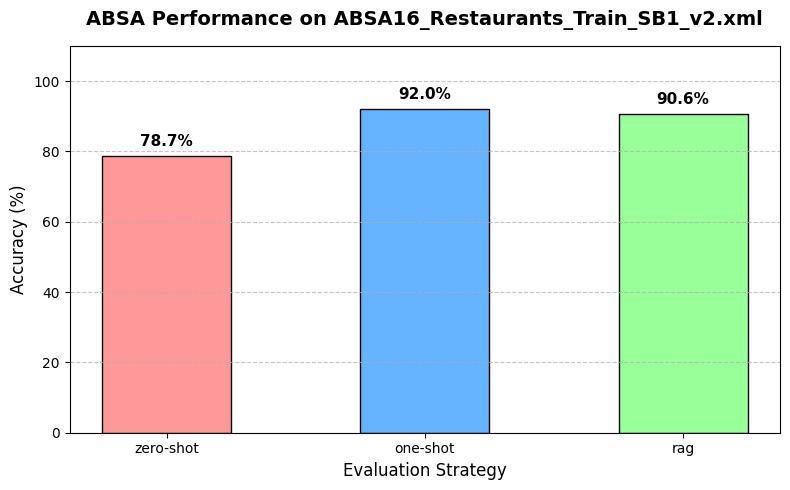

In [ ]:
import os
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

# 1. set your XML path here
XML_FILE_PATH = "ABSA16_Restaurants_Train_SB1_v2.xml"  # your train XML filename or path

# verify file exists
if not os.path.exists(XML_FILE_PATH):
    raise FileNotFoundError(f"File not found: {XML_FILE_PATH}")

# 2. read XML as a string
def load_xml_file(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        return f.read()

# load main XML
xml_dataset = load_xml_file(XML_FILE_PATH)

# 3. methods to evaluate
modes = ["zero-shot", "one-shot", "rag"]
accuracy_results = {}

print(f"--- Starting Full Evaluation on {XML_FILE_PATH} ---")

# run all three scenarios on real data
for mode in modes:
    print(f"\nRunning evaluation for: {mode.upper()}...")

    # eval on full parsed dataset
    results = evaluate_absa(xml_dataset, mode=mode)

    # accuracy on your file
    if len(results) > 0:
        correct = sum(1 for r in results if r["true"] == r["pred"])
        accuracy = (correct / len(results)) * 100
    else:
        accuracy = 0.0

    accuracy_results[mode] = accuracy
    print(f"-> Total Samples Evaluated: {len(results)}")
    print(f"-> Result for {mode.upper()}: Accuracy = {accuracy:.2f}%")

# ==========================================
# 4. comparison plot from your data
# ==========================================
plt.figure(figsize=(8, 5))
colors = ['#ff9999', '#66b3ff', '#99ff99']

bars = plt.bar(accuracy_results.keys(), accuracy_results.values(), color=colors, edgecolor='black', width=0.5)

# chart cosmetics
plt.title(f'ABSA Performance on {XML_FILE_PATH}', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Evaluation Strategy', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# percent labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 2, f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()